In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv(r"E:\Visualization\Lab_main\Data\athlete_events.csv")
df.head(5)

,ID,me,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,Chi,CHN,1992 Summer,1992,Summer,Barcelo,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,Chi,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunr Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindeu Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN


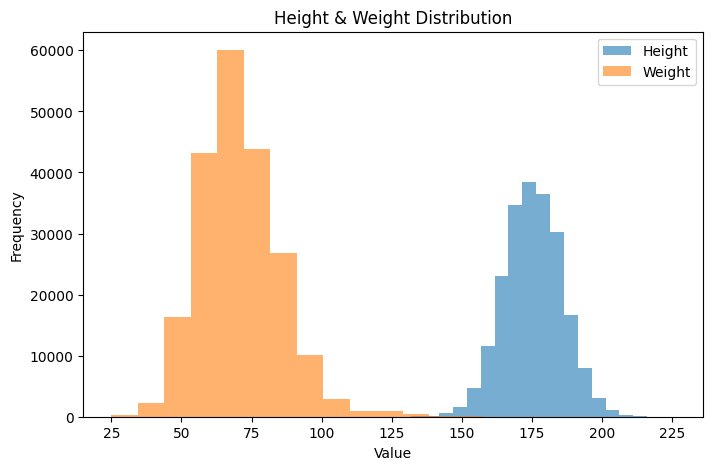

In [4]:

plt.figure(figsize=(8,5))

plt.hist(df['Height'], bins=20, alpha=0.6, label='Height')
plt.hist(df['Weight'], bins=20, alpha=0.6, label='Weight')

plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Height & Weight Distribution")

plt.legend()
plt.show()

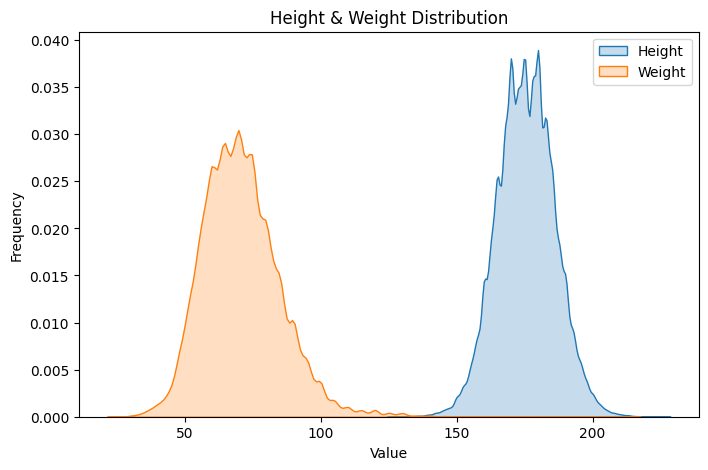

In [5]:
plt.figure(figsize=(8,5))
sns.kdeplot(df['Height'],label='Height',fill=True)
sns.kdeplot(df['Weight'],label='Weight',fill=True)

plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Height & Weight Distribution")

plt.legend()
plt.show()

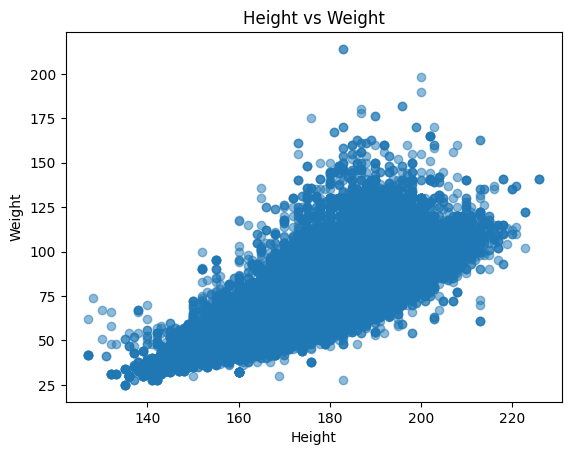

In [6]:
plt.scatter(df['Height'], df['Weight'], alpha=0.5)

plt.xlabel("Height")
plt.ylabel("Weight")
plt.title("Height vs Weight")

plt.show()

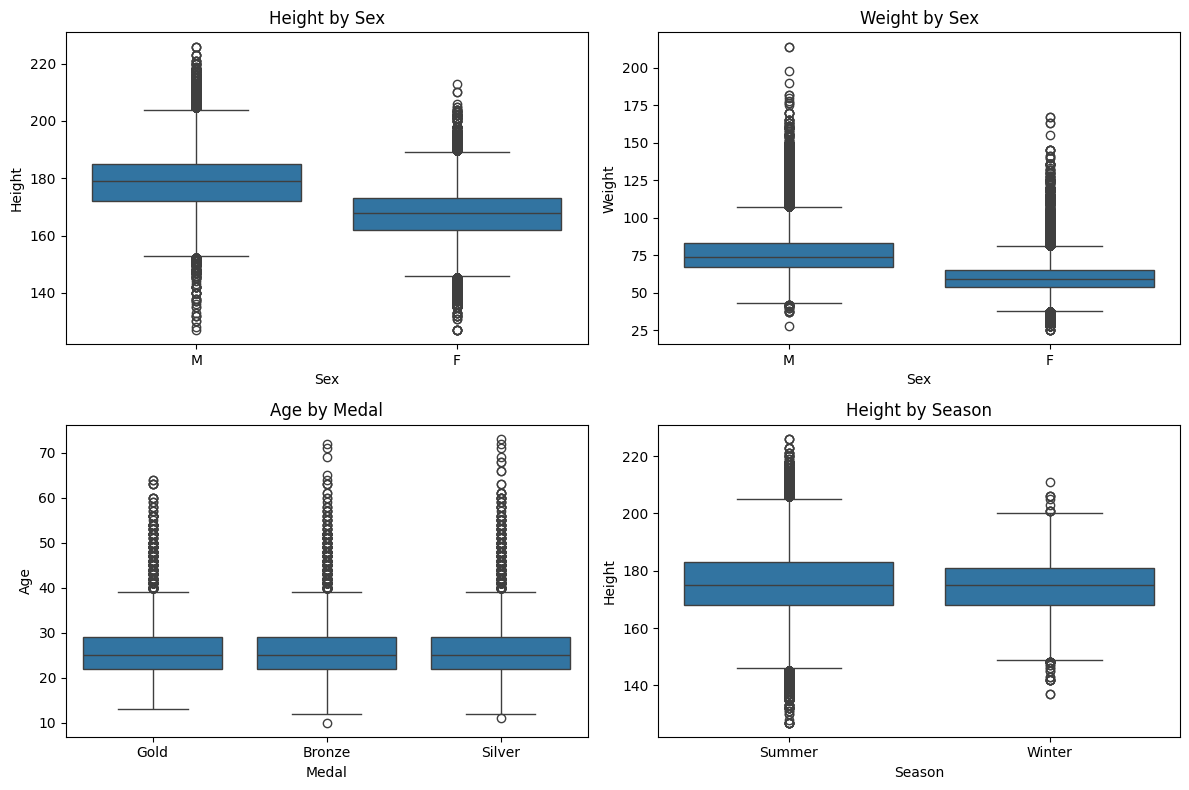

In [7]:


fig, ax = plt.subplots(2, 2, figsize=(12, 8))


sns.boxplot(x='Sex', y='Height', data=df, ax=ax[0,0])
ax[0,0].set_title("Height by Sex")


sns.boxplot(x='Sex', y='Weight', data=df, ax=ax[0,1])
ax[0,1].set_title("Weight by Sex")


sns.boxplot(x='Medal', y='Age', data=df, ax=ax[1,0])
ax[1,0].set_title("Age by Medal")


sns.boxplot(x='Season', y='Height', data=df, ax=ax[1,1])
ax[1,1].set_title("Height by Season")

plt.tight_layout()
plt.show()

# Bai 2

In [8]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv"

df2 = pd.read_csv(url)

print(df2.head(12))

          Date  Temp
0   1981-01-01  20.7
1   1981-01-02  17.9
2   1981-01-03  18.8
3   1981-01-04  14.6
4   1981-01-05  15.8
5   1981-01-06  15.8
6   1981-01-07  15.8
7   1981-01-08  17.4
8   1981-01-09  21.8
9   1981-01-10  20.0
10  1981-01-11  16.2
11  1981-01-12  13.3


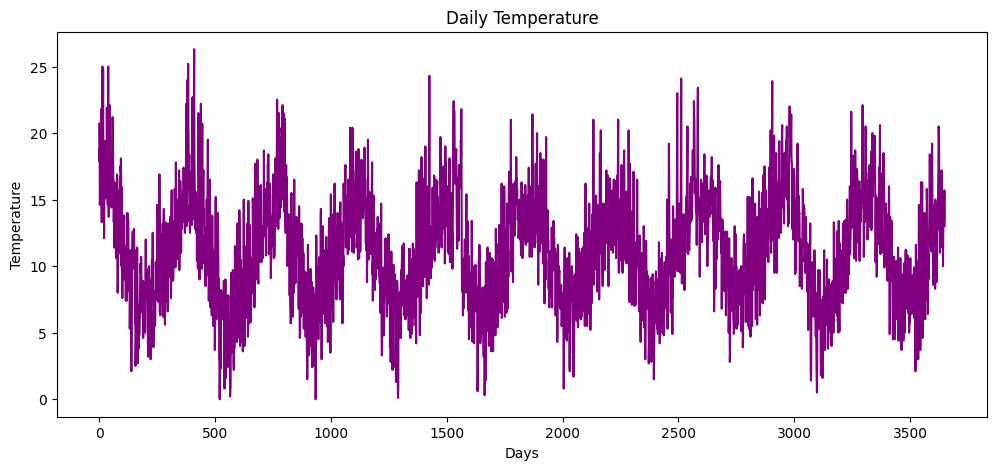

In [9]:

plt.figure(figsize=(12,5))

plt.plot(df2['Temp'],color='purple')

plt.title("Daily Temperature")
plt.xlabel("Days")
plt.ylabel("Temperature")

plt.show()

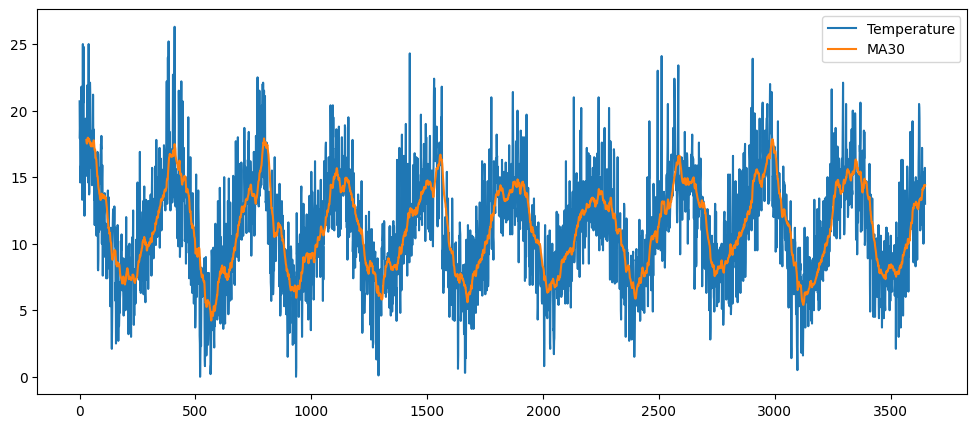

In [10]:
df2['MA30'] = df2['Temp'].rolling(window=30).mean()
plt.figure(figsize=(12,5))

plt.plot(df2['Temp'], label='Temperature')
plt.plot(df2['MA30'], label='MA30')

plt.legend()
plt.show()

# Bai 3

In [11]:
df = df.drop('ID', axis=1)

In [12]:
numeric_cols = df.select_dtypes(include='number').columns

for col in numeric_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col}")
    print(f"Outliers: {len(outliers)}")

    print(outliers[[col]].head())

Age
Outliers: 10317
      Age
58   54.0
89   43.0
90   47.0
124  41.0
126  45.0
Height
Outliers: 1338
      Height
443    207.0
820    210.0
1186   208.0
1322   208.0
1622   140.0
Weight
Outliers: 3237
     Weight
57    130.0
80    125.0
384   120.0
507   117.5
508   117.5
Year
Outliers: 380
      Year
3079  1896
3080  1896
3081  1896
3082  1896
7348  1896


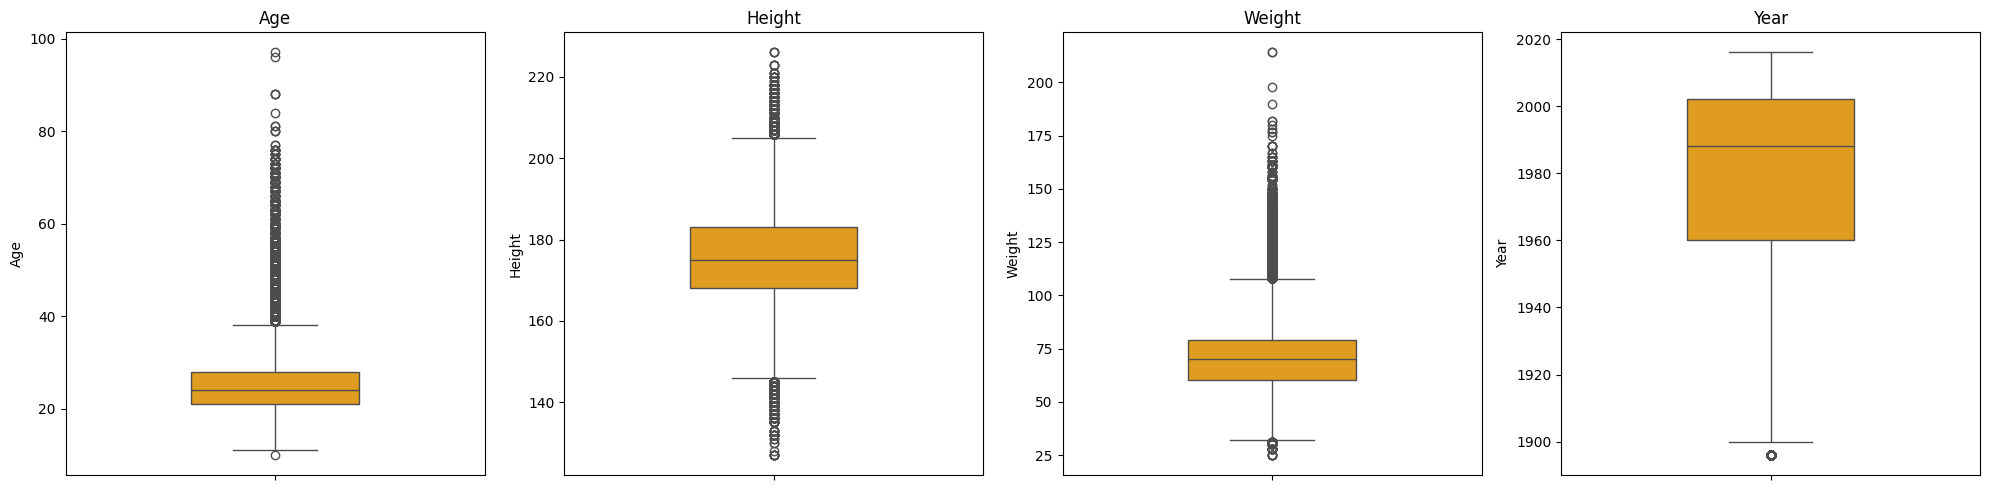

In [13]:
numeric_cols = df.select_dtypes(include='number').columns

fig, ax = plt.subplots(1, len(numeric_cols), figsize=(20,5))

for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df[col], ax=ax[i],color='orange',width=0.4)
    ax[i].set_title(col)

plt.tight_layout()
plt.show()

In [14]:
df = df[(df['Weight'] > 20) & (df['Weight'] < 300)]

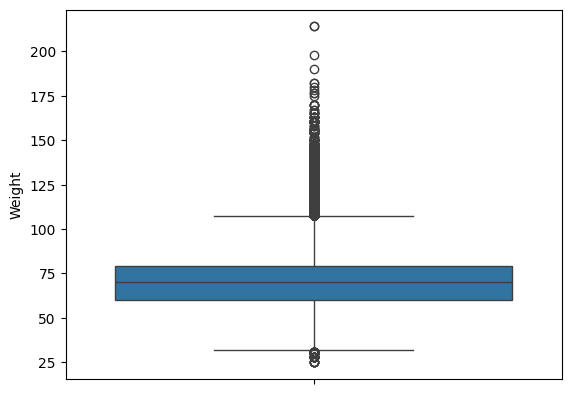

In [15]:
sns.boxplot(y=df['Weight'])
plt.show()

# Bai 4

In [16]:
corr_matrix= df.corr(numeric_only=True)
print(corr_matrix)

             Age    Height    Weight      Year
Age     1.000000  0.141684  0.212069  0.082940
Height  0.141684  1.000000  0.796213  0.048954
Weight  0.212069  0.796213  1.000000  0.019095
Year    0.082940  0.048954  0.019095  1.000000


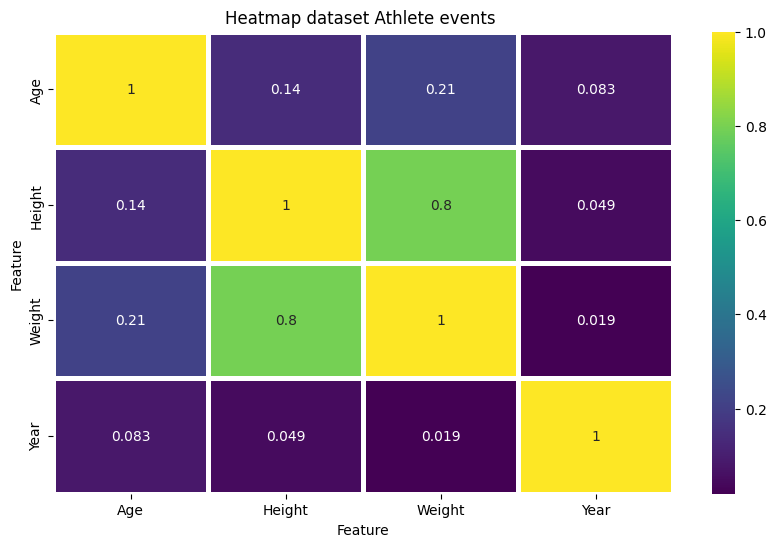

In [17]:
plt.figure(figsize=(10,6))
sns.heatmap(
    corr_matrix,
    cmap='viridis',
    annot=True,
    linecolor='white',
    linewidths=3.5
)
plt.title('Heatmap dataset Athlete events ')
plt.xlabel('Feature')
plt.ylabel('Feature')
plt.show()

# Bai lam them

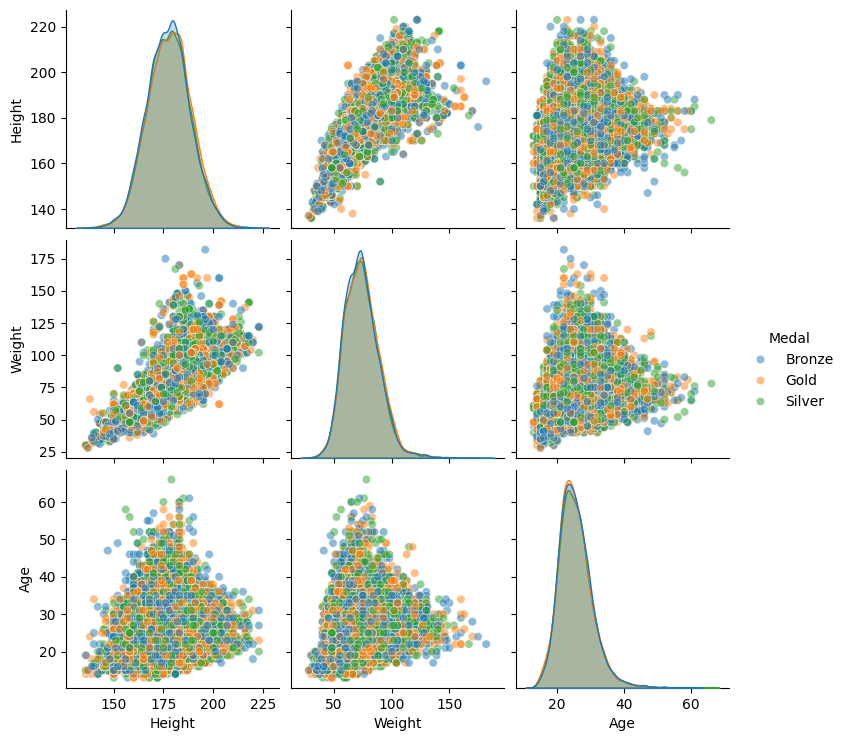

In [19]:
features = ["Height", "Weight", "Age"]

df_clean = df.dropna(subset=features + ["Medal"])
sns.pairplot(
    df_clean,
    vars=features,
    hue="Medal",
    diag_kind="kde",
    plot_kws={"alpha": 0.5}
)

plt.show()

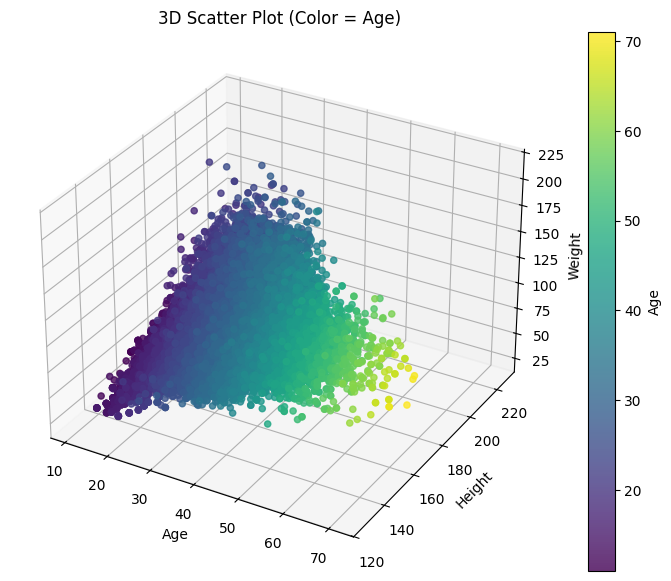

In [22]:

from mpl_toolkits.mplot3d import Axes3D

df_clean = df.dropna(subset=["Age", "Height", "Weight"])

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(
    df_clean["Age"],
    df_clean["Height"],
    df_clean["Weight"],
    c=df_clean["Age"],      # COLOR MAP THEO AGE
    cmap="viridis",         
    s=20,
    alpha=0.8
)

ax.set_xlabel("Age")
ax.set_ylabel("Height")
ax.set_zlabel("Weight")
ax.set_title("3D Scatter Plot (Color = Age)")

cbar = plt.colorbar(sc)
cbar.set_label("Age")

plt.show()